# Beat-This on Jazz Trio Database — Evaluation Report

End-to-end analysis of the **beat_this** model on the JTD dataset (1,294 tracks).
Each track has been scored with the standard `mir_eval` beat-tracking metrics
(F-measure, Cemgil, Goto, P-score, CMLc/t, AMLc/t, Information Gain) for both
**beats** and **downbeats**.


In [26]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Audio + model imports are optional: the heavy analysis cells below
# only need the CSV + .npz prediction files and should run even when
# soxr/torch/librosa are missing in the kernel.
try:
    import librosa
    import IPython.display as ipd
    AUDIO_OK = True
except Exception as e:
    print(f'[warn] audio stack unavailable ({e!r}); single-track playback cells will be skipped.')
    AUDIO_OK = False

try:
    from scripts.support_function import plot_beats
    from scripts.run_beat_this import run_beat_this
    MODEL_OK = True
except Exception as e:
    print(f'[warn] model stack unavailable ({e!r}); inference cells will be skipped.')
    MODEL_OK = False

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})


## 1 — Load & enrich evaluation data


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
RESULTS_CSV = Path('csvs/beat_this_jtd_finetuned_enriched.csv')
if not RESULTS_CSV.exists():
    RESULTS_CSV = Path('csvs/beat_this_jtd_finetuned_enriched.csv')
PREDS_DIR  = Path('preds')

df = pd.read_csv(RESULTS_CSV)

# JTD track ids look like:
#   <leaderInstrument>-<song>-<sidemen>-<year>-<hash>
# e.g. 'barronk-allgodschildren-drummondrrileyb-1990-8b77c067'
parts = df['track_id'].str.split('-', expand=True)
df['leader'] = parts[0]
year_col = parts.iloc[:, -2]
df['year'] = pd.to_numeric(year_col, errors='coerce').astype('Int64')
df['decade'] = (df['year'] // 10 * 10).astype('Int64')

# Ensure time_signature is present
if 'time_signature' not in df.columns:
    df['time_signature'] = 4  # Default to 4 if unknown

# Track length in beats and approx. seconds (using inferred mean tempo of 120 BPM as floor;
# we'll get a sharper estimate from the .npz files later).
df['beat_count_diff'] = df['n_pred_beats'] - df['n_gt_beats']
df['downbeat_count_diff'] = df['n_pred_downbeats'] - df['n_gt_downbeats']
df['beat_count_ratio'] = df['n_pred_beats'] / df['n_gt_beats']
df['downbeat_count_ratio'] = df['n_pred_downbeats'] / df['n_gt_downbeats']

print(f'Loaded {len(df):,} tracks   |   {df["leader"].nunique()} unique leaders   |   '
      f'years {int(df["year"].min())}–{int(df["year"].max())}')
print(f'Status breakdown: {df["status"].value_counts().to_dict()}')
df.head(5)


Loaded 1,294 tracks   |   29 unique leaders   |   years 1947–2015
Status breakdown: {'ok': 1294}


,track_id,audio_path,n_gt_beats,n_pred_beats,n_gt_downbeats,n_pred_downbeats,infer_seconds,status,beat_F-measure,beat_Cemgil,...,downbeat_AMLt,downbeat_Information gain,time_signature,leader,year,decade,beat_count_diff,downbeat_count_diff,beat_count_ratio,downbeat_count_ratio
0,barronk-allgodschildren-drummondrrileyb-1990-8...,/home/rht9410/jtd_data/barronk-allgodschildren...,762,762,190,328,1.773,ok,0.998645,0.737387,...,0.252366,0.497507,4,barronk,1990,1990,0,138,1.000000,1.726316
1,barronk-beautifullove-mrazgrileyb-2009-c87abfa6,/home/rht9410/jtd_data/barronk-beautifullove-m...,249,250,62,62,0.204,ok,1.000000,0.941169,...,1.000000,0.867395,4,barronk,2009,2000,1,0,1.004016,1.000000
2,barronk-bebop-hadenchaynesr-1994-cd0e18ee,/home/rht9410/jtd_data/barronk-bebop-hadenchay...,600,607,150,235,0.480,ok,0.979661,0.826233,...,0.401747,0.510297,4,barronk,1994,1990,7,85,1.011667,1.566667
3,barronk-bemshaswing-reidrwaitsf-1984-05bc9ae9,/home/rht9410/jtd_data/barronk-bemshaswing-rei...,633,635,158,193,0.415,ok,0.999190,0.963420,...,0.638298,0.720246,4,barronk,1984,1980,2,35,1.003160,1.221519
4,barronk-bemshaswing-reidrwaitsf-1984-51c9b63f,/home/rht9410/jtd_data/barronk-bemshaswing-rei...,637,638,159,194,0.421,ok,1.000000,0.964282,...,0.640212,0.724947,4,barronk,1984,1980,1,35,1.001570,1.220126


## 2 — Headline performance numbers

Across all 1,294 tracks, summarise every metric with mean / median / std and
the share of tracks crossing the usual quality bands (>0.9 = excellent,
>0.7 = good, >0.5 = fair, ≤0.5 = poor).

### Metric definitions

All metrics come from `mir_eval.beat`. They are applied twice — once to the
list of beat times and once to the list of downbeat times — yielding the
`beat_*` and `downbeat_*` columns. Unless noted, scores are in **[0, 1]**
and higher is better.

| Metric | What it measures | Tolerance / detail |
|---|---|---|
| **F-measure** | Harmonic mean of precision and recall over predicted vs. reference events. | A prediction counts as correct if it falls within **±70 ms** of a reference event. |
| **Cemgil** | Sum of Gaussians centred on each reference event, evaluated at each prediction; normalised by `max(N_pred, N_ref)`. | Gaussian σ = **40 ms** — softer than F-measure: small timing errors are penalised proportionally rather than discretely. |
| **Goto** | Binary {0, 1} indicator of whether the system tracked the beat "well" overall. | Returns 1 only if the longest correctly-tracked segment covers **≥ 25 %** of the track *and* the inter-beat intervals are stable. Tolerates one large error; otherwise 0. |
| **P-score** | Normalised cross-correlation of impulse trains representing reference and predicted beats. | Tolerance window is **20 % of the median reference IBI** (so it adapts to tempo). |
| **CMLc** | *Correct Metrical Level — continuous.* The **longest contiguous** stretch tracked at the same metrical level as the reference, divided by track length. | Strict: predictions must match the reference tempo and phase. |
| **CMLt** | *Correct Metrical Level — total.* The **total** time correctly tracked at the same metrical level (not necessarily contiguous). | Same strictness as CMLc, but rewards intermittent recovery. |
| **AMLc** | *Allowed Metrical Levels — continuous.* Like CMLc, but **octave errors are allowed** (half-tempo, double-tempo, off-beat by half a beat). | Useful for separating "wrong tempo" from "wrong phase" failures. |
| **AMLt** | *Allowed Metrical Levels — total.* Like CMLt with the same octave-error allowance. | Highest of the four CML/AML scores by construction. |
| **Information gain** | Information-theoretic measure: mutual information between the histogram of beat errors and a uniform distribution. | Reported in **bits**; range is `[0, log₂(num_bins)] ≈ [0, 5.3]`. Higher = errors are tightly concentrated near zero. |

> **Note on the NaN columns.** `beat_CMLc/CMLt/AMLc/AMLt` and their downbeat
> counterparts are all empty in this CSV — the evaluation script we ran did
> not request those continuity scores. They are listed above for completeness
> and will be filtered out of the correlation heatmap automatically.

> **Beat vs. downbeat metrics.** The two families use the *same definitions*
> applied to different event lists. Beats = every pulse; downbeats = the "1"
> of each bar only. Downbeat scores are therefore much more sensitive to
> **phase / metre** errors: a tracker can hit every beat perfectly yet still
> score 0 on `downbeat_F-measure` if it locks onto beat 2 instead of beat 1.


In [28]:
metric_cols = [c for c in df.columns if c.startswith('beat_') or c.startswith('downbeat_')]
metric_cols = [c for c in metric_cols if c not in ('beat_count_diff','beat_count_ratio',
                                                    'downbeat_count_diff','downbeat_count_ratio')]

summary = df[metric_cols].agg(['mean','median','std','min','max']).T
summary['n_valid'] = df[metric_cols].notna().sum().values
summary = summary.round(3)
summary


,mean,median,std,min,max,n_valid
beat_F-measure,0.969,0.998,0.068,0.468,1.000,1294
beat_Cemgil,0.841,0.863,0.107,0.351,0.978,1294
beat_Goto,0.844,1.000,0.363,0.000,1.000,1294
beat_P-score,0.955,0.995,0.086,0.447,1.000,1294
beat_CMLc,0.700,0.855,0.349,0.000,1.000,1294
beat_CMLt,0.914,0.989,0.162,0.000,1.000,1294
beat_AMLc,0.703,0.857,0.346,0.007,1.000,1294
beat_AMLt,0.919,0.990,0.143,0.105,1.000,1294
beat_Information gain,0.523,0.539,0.107,0.039,0.755,1294
downbeat_F-measure,0.683,0.706,0.235,0.000,1.000,1294


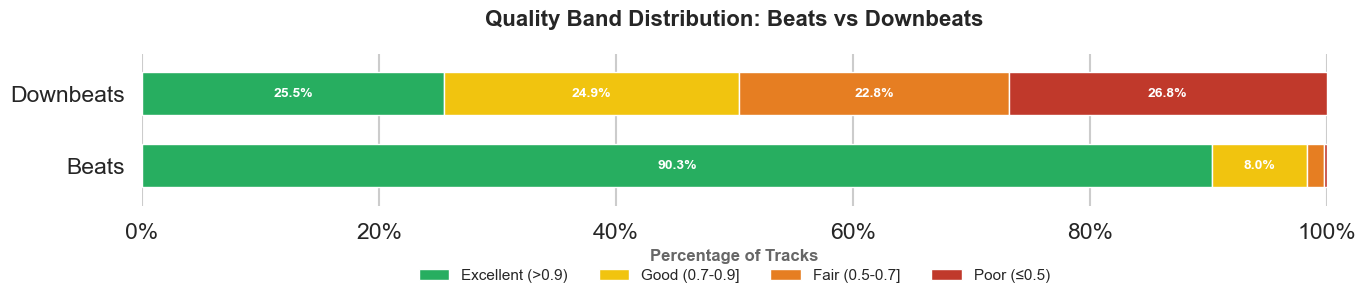

,Beats,Downbeats
Excellent (>0.9),90.3%,25.5%
Good (0.7-0.9],8.0%,24.9%
Fair (0.5-0.7],1.4%,22.8%
Poor (≤0.5),0.2%,26.8%


In [29]:
def bands(series):
    s = series.dropna()
    return pd.Series({
        'Excellent (>0.9)': (s > 0.9).mean(),
        'Good (0.7-0.9]':   ((s > 0.7) & (s <= 0.9)).mean(),
        'Fair (0.5-0.7]':   ((s > 0.5) & (s <= 0.7)).mean(),
        'Poor (≤0.5)':      (s <= 0.5).mean(),
    })

band_df = pd.DataFrame({
    'Beats':     bands(df['beat_F-measure']),
    'Downbeats': bands(df['downbeat_F-measure']),
})

colors = ['#27ae60', '#f1c40f', '#e67e22', '#c0392b']
ax = (band_df * 100).T.plot(kind='barh', stacked=True, figsize=(14, 4.5),
                            color=colors, width=0.6, edgecolor='white', linewidth=1)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage of Tracks', fontsize=12, fontweight='bold', alpha=0.7)
ax.set_title('Quality Band Distribution: Beats vs Downbeats', fontsize=16, pad=20)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.6), ncol=4, frameon=False, fontsize=11)

for c in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

(band_df * 100).round(1).astype(str) + '%'

## 4 — Performance by Metre

Analyze how the model performs across different time signatures (metres). This helps identify if the model has a bias towards 4/4 time or struggles with 3/4 (waltz) feels.

In [30]:
# Frequency breakdown of all metres in the dataset
meter_counts = df['time_signature'].value_counts().sort_index()
print(f"Total Tracks analyzed: {len(df):,}")
print("Breakdown of Metres in JTD Dataset:")
for meter, count in meter_counts.items():
    print(f"- {meter}/4: {count} tracks")

Total Tracks analyzed: 1,294
Breakdown of Metres in JTD Dataset:
- 3/4: 90 tracks
- 4/4: 1204 tracks


Performance Statistics by Metre:


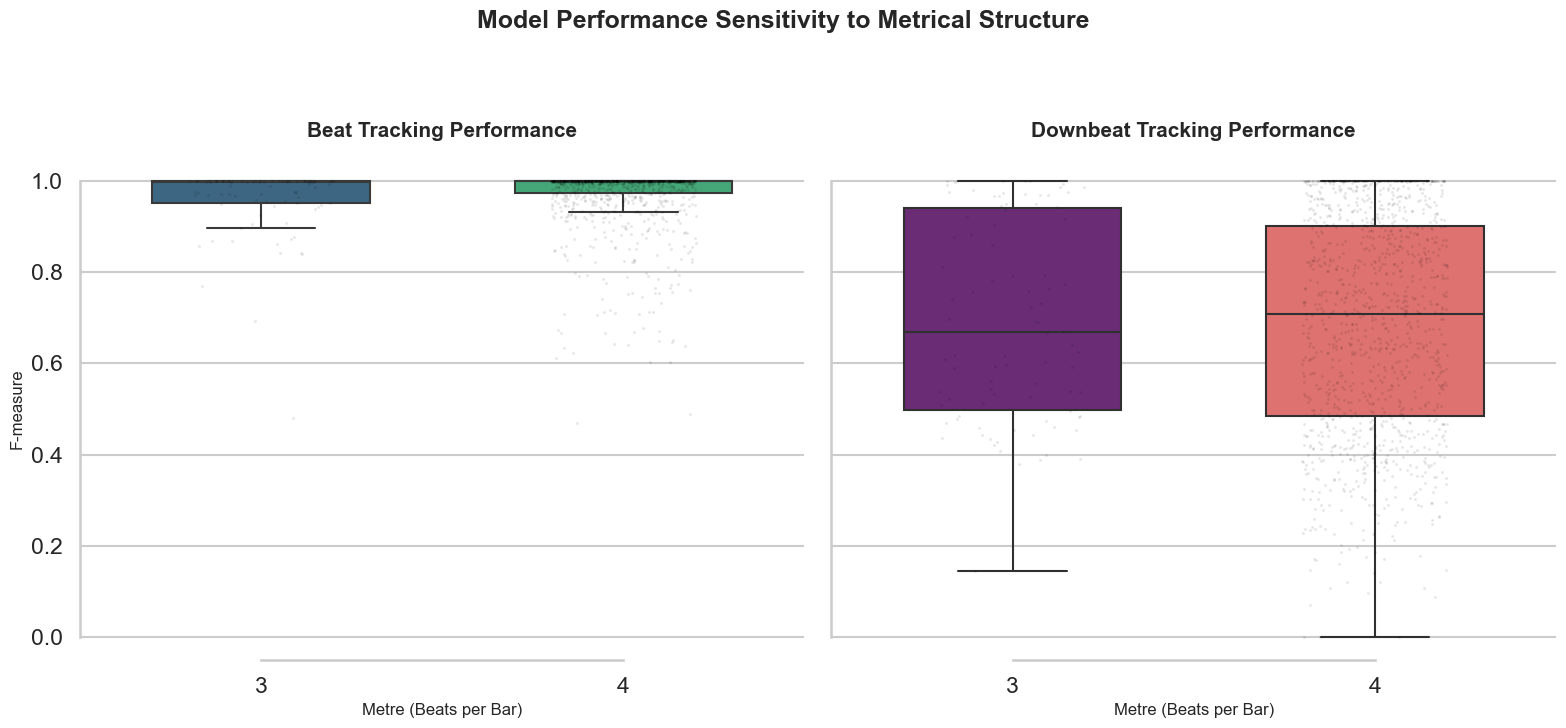

In [31]:
# Group by metre and calculate average performance
metre_stats = df.groupby('time_signature')[['beat_F-measure', 'downbeat_F-measure']].agg(['mean', 'median', 'std', 'count'])

# Display stats with premium formatting
print("Performance Statistics by Metre:")
display(metre_stats.style.format("{:.3f}").background_gradient(cmap='Blues'))

# Visualization - Premium UI
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Beat F-measure by metre
sns.boxplot(x='time_signature', y='beat_F-measure', data=df, ax=axes[0], 
            palette='viridis', width=0.6, showfliers=False, linewidth=1.5)
sns.stripplot(x='time_signature', y='beat_F-measure', data=df, ax=axes[0], 
              color='black', alpha=0.1, size=2, jitter=0.2)
axes[0].set_title('Beat Tracking Performance', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Metre (Beats per Bar)', fontsize=12)
axes[0].set_ylabel('F-measure', fontsize=12)

# Downbeat F-measure by metre
sns.boxplot(x='time_signature', y='downbeat_F-measure', data=df, ax=axes[1], 
            palette='magma', width=0.6, showfliers=False, linewidth=1.5)
sns.stripplot(x='time_signature', y='downbeat_F-measure', data=df, ax=axes[1], 
              color='black', alpha=0.1, size=2, jitter=0.2)
axes[1].set_title('Downbeat Tracking Performance', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Metre (Beats per Bar)', fontsize=12)

plt.suptitle('Model Performance Sensitivity to Metrical Structure', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
sns.despine(trim=True)
plt.show()

### Beat and Downbeat Errors by Metre

Direct comparison of the tracking error (1 - F-measure) for both beats and downbeats across different metres.

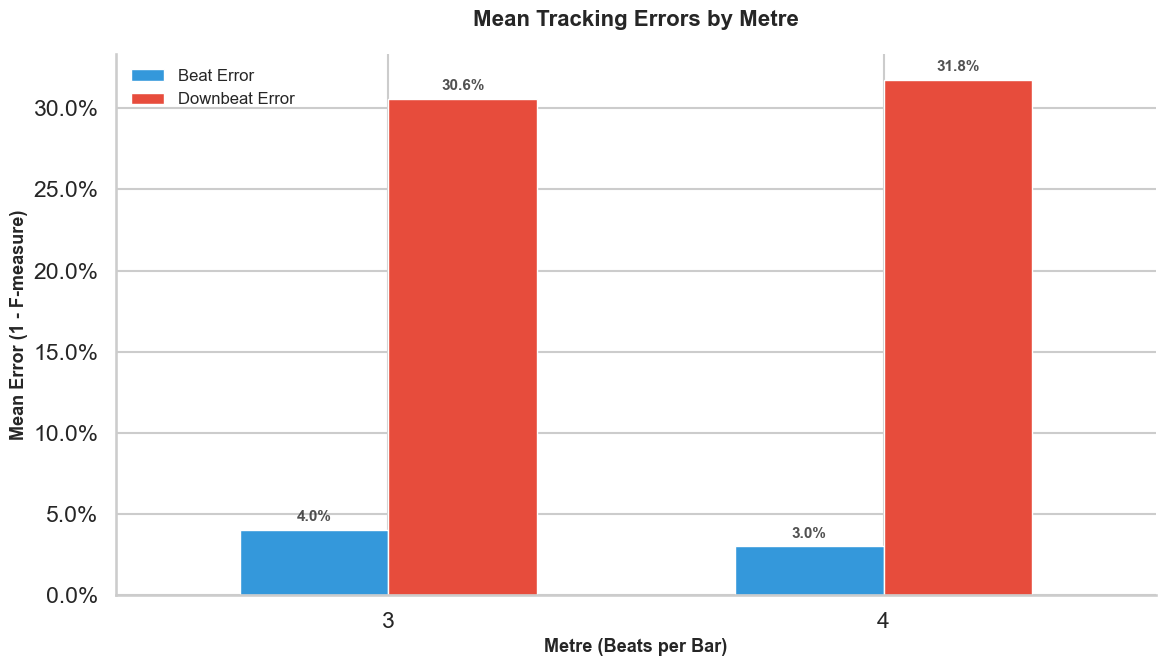

In [32]:
# Calculate errors
df['beat_error'] = 1 - df['beat_F-measure']
df['downbeat_error'] = 1 - df['downbeat_F-measure']

# Group by metre and calculate mean errors
error_stats = df.groupby('time_signature')[['beat_error', 'downbeat_error']].mean() * 100

# Visualization of errors - Premium UI
fig, ax = plt.subplots(figsize=(12, 7))

error_stats.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.6, edgecolor='white', linewidth=1)
ax.set_title('Mean Tracking Errors by Metre', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Metre (Beats per Bar)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Error (1 - F-measure)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(['Beat Error', 'Downbeat Error'], frameon=False, fontsize=12)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', alpha=0.8)

plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Score distributions

Histogram + ECDF for the two headline F-measures. Vertical lines show the
median (solid) and the 25/75th percentiles (dashed) so you can read off
the bulk of the distribution at a glance.


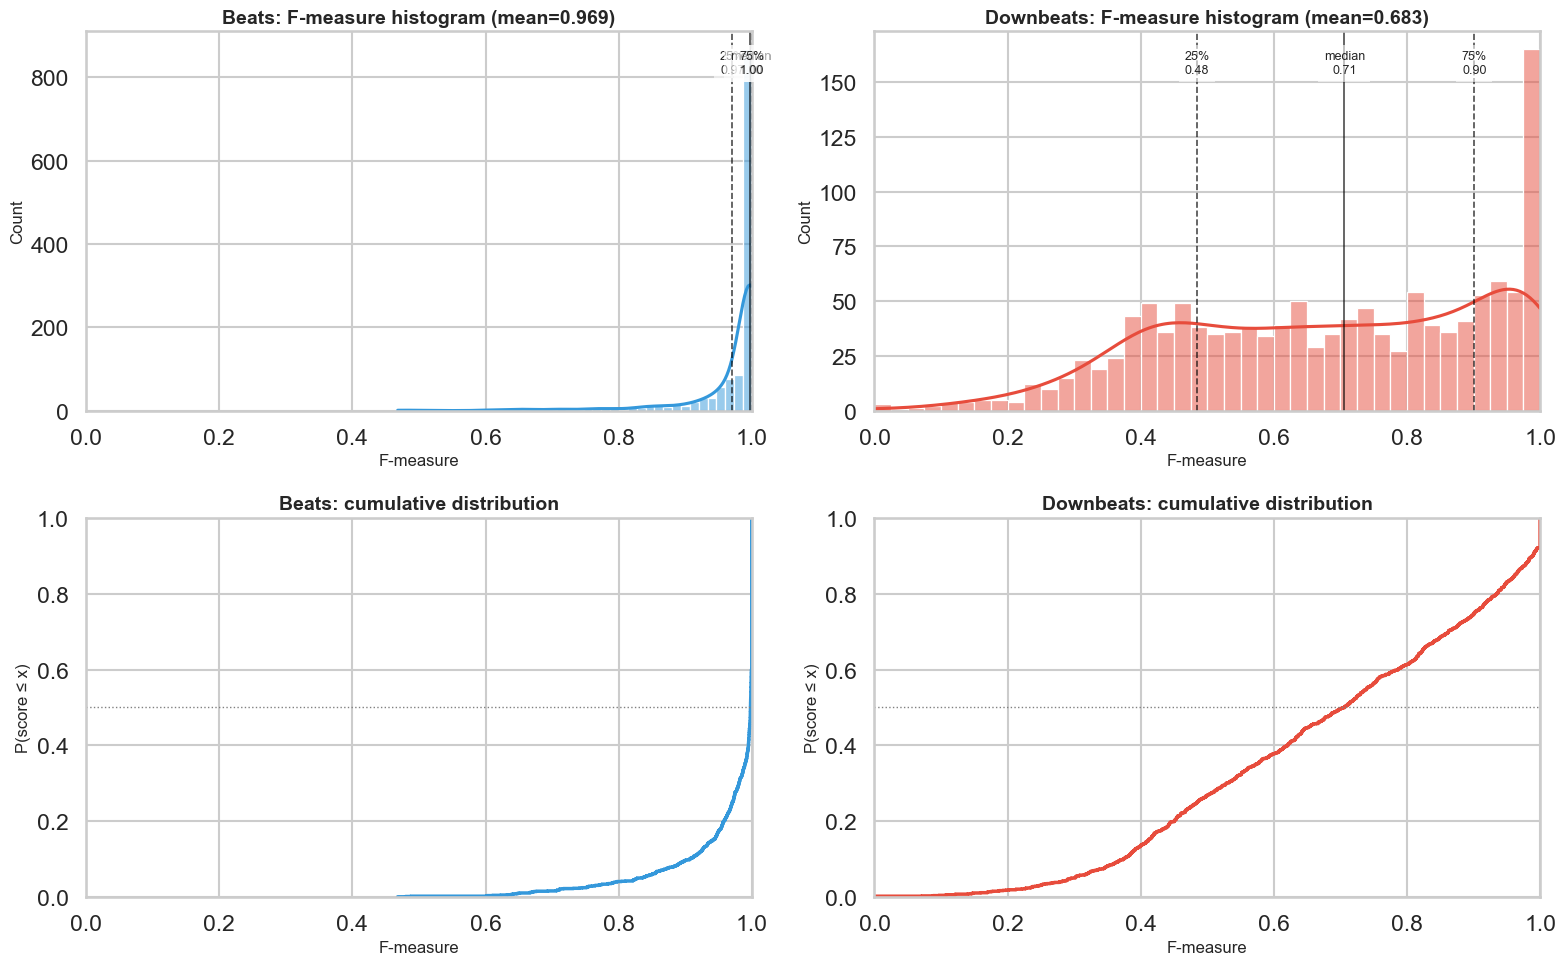

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
pairs = [('beat_F-measure','#3498db','Beats'),
         ('downbeat_F-measure','#e74c3c','Downbeats')]

for col_idx, (metric, color, label) in enumerate(pairs):
    series = df[metric].dropna()
    ax_h, ax_e = axes[0, col_idx], axes[1, col_idx]

    sns.histplot(series, bins=40, kde=True, color=color, ax=ax_h, edgecolor='white')
    q1, med, q3 = series.quantile([0.25, 0.5, 0.75])
    for q, ls, lbl in [(q1,'--','25%'),(med,'-','median'),(q3,'--','75%')]:
        ax_h.axvline(q, color='black', ls=ls, lw=1.2, alpha=0.7)
        ax_h.text(q, ax_h.get_ylim()[1]*0.95, f'{lbl}\n{q:.2f}', ha='center',
                  fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    ax_h.set_xlim(0, 1)
    ax_h.set_title(f'{label}: F-measure histogram (mean={series.mean():.3f})')
    ax_h.set_xlabel('F-measure')

    sns.ecdfplot(series, color=color, lw=2.5, ax=ax_e)
    ax_e.set_xlim(0, 1); ax_e.set_ylim(0, 1)
    ax_e.axhline(0.5, color='gray', ls=':', lw=1)
    ax_e.set_title(f'{label}: cumulative distribution')
    ax_e.set_xlabel('F-measure'); ax_e.set_ylabel('P(score ≤ x)')

plt.tight_layout(); plt.show()


## 4 — All metrics side-by-side

Boxplots with raw points overlayed (a *strip* plot). Useful for spotting
metrics whose tails are very different from the median — e.g. Goto is
binary-ish so its box collapses, while Information Gain has a much wider
spread than F-measure.


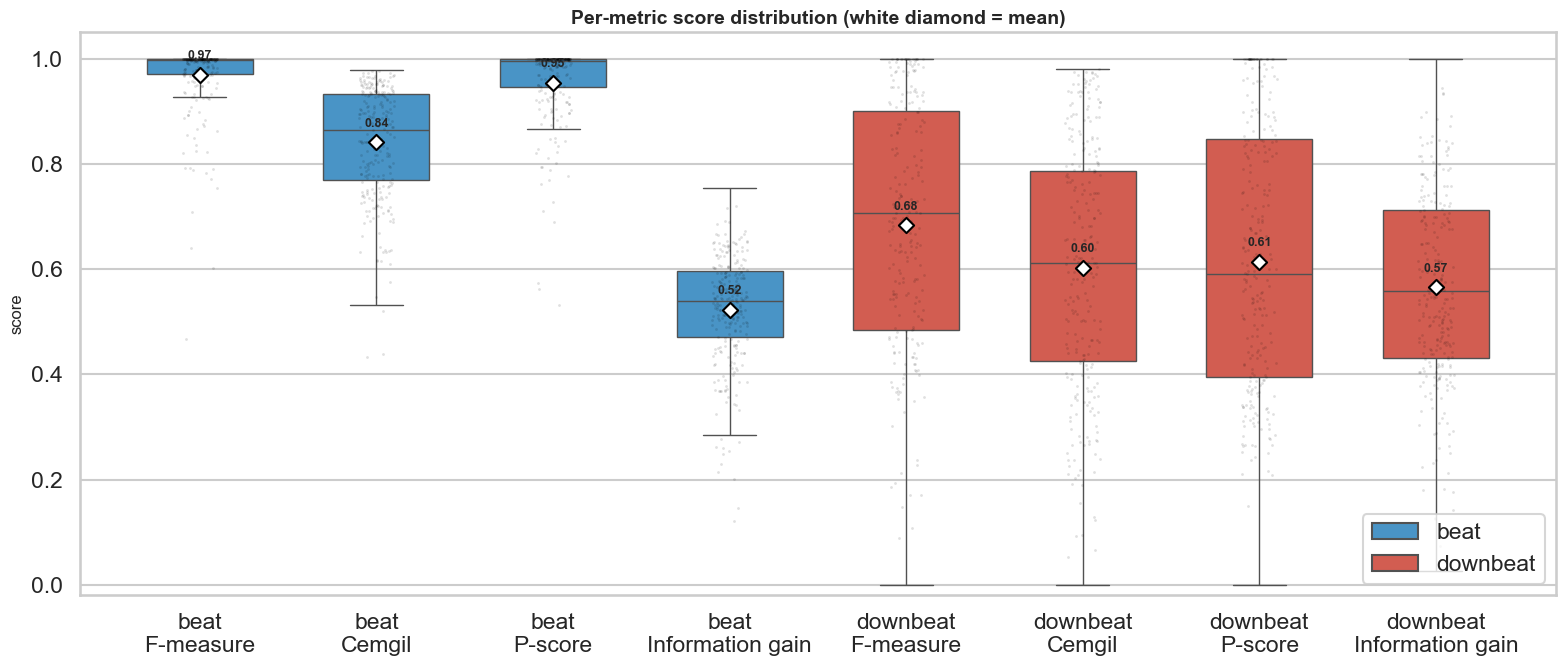

In [34]:
plot_cols = [
    'beat_F-measure','beat_Cemgil','beat_P-score','beat_Information gain',
    'downbeat_F-measure','downbeat_Cemgil','downbeat_P-score','downbeat_Information gain',
]
melted = df[plot_cols].melt(var_name='metric', value_name='score').dropna()
melted['domain'] = melted['metric'].str.split('_').str[0]

plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='metric', y='score', data=melted, hue='domain',
                 palette={'beat':'#3498db','downbeat':'#e74c3c'},
                 width=0.6, fliersize=0, dodge=False)
sns.stripplot(x='metric', y='score', data=melted.sample(n=min(2000, len(melted)), random_state=0),
              color='black', alpha=0.12, size=2, ax=ax)
for i, m in enumerate(plot_cols):
    mu = df[m].mean()
    ax.scatter(i, mu, marker='D', color='white', edgecolor='black', s=60, zorder=5)
    ax.text(i, mu + 0.03, f'{mu:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Per-metric score distribution (white diamond = mean)')
ax.set_xticklabels([t.get_text().replace('_','\n') for t in ax.get_xticklabels()], rotation=0)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(''); ax.legend(title='', loc='lower right')
plt.tight_layout(); plt.show()


## 5 — How do the metrics co-vary?

Pearson correlation across every numeric metric. Tight clusters reveal
metrics that essentially measure the same thing (e.g. beat-F vs beat-Cemgil),
while a low cross-block correlation tells us downbeat tracking is a
**genuinely separate failure mode** from beat tracking.


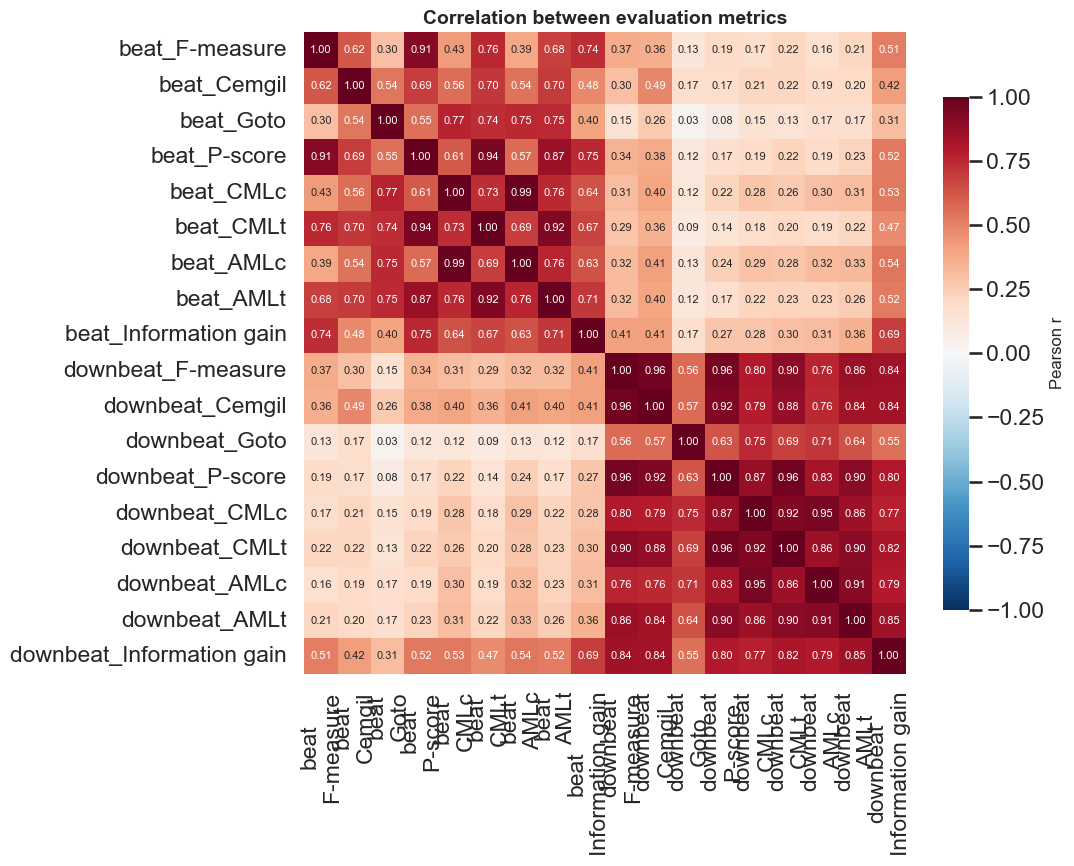

In [35]:
corr_cols = [c for c in metric_cols if df[c].notna().sum() > 100]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}, ax=ax,
            xticklabels=[c.replace('_','\n') for c in corr.columns],
            yticklabels=corr.index)
ax.set_title('Correlation between evaluation metrics')
plt.tight_layout(); plt.show()


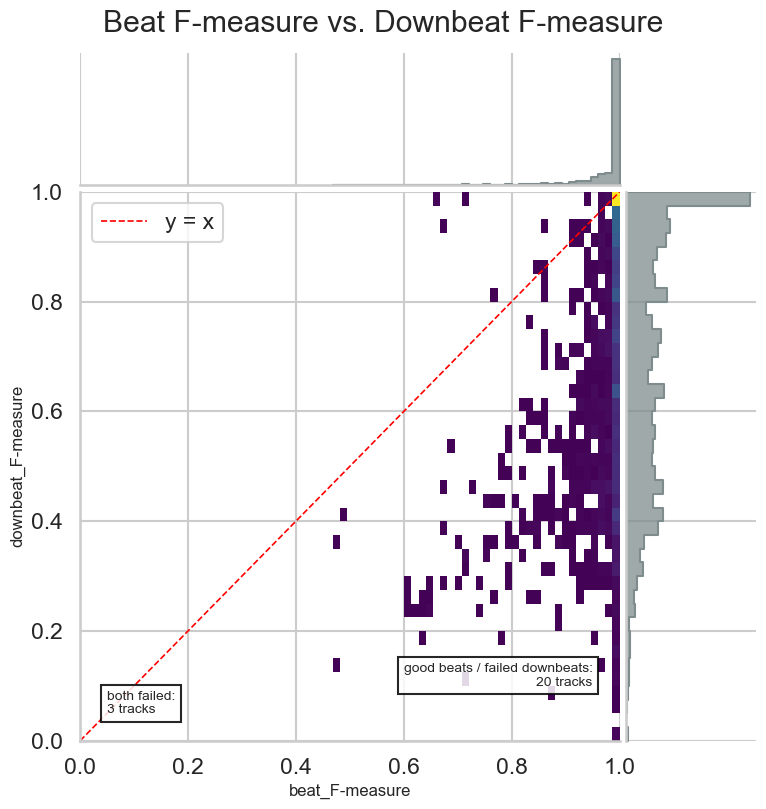

Pearson r(beat_F, downbeat_F) = 0.371


In [36]:
# Joint plot: beat F vs downbeat F with marginal distributions, colored by data density.
g = sns.JointGrid(data=df, x='beat_F-measure', y='downbeat_F-measure',
                  height=8, ratio=4, space=0.05)
g.plot_joint(sns.histplot, bins=40, pmax=0.9, cmap='viridis', cbar=False)
g.plot_marginals(sns.histplot, bins=40, color='#7f8c8d', element='step')
g.ax_joint.plot([0,1],[0,1], color='red', ls='--', lw=1.2, label='y = x')

# Highlight failure quadrants.
good_b_bad_db = ((df['beat_F-measure'] > 0.8) & (df['downbeat_F-measure'] < 0.2)).sum()
both_bad     = ((df['beat_F-measure'] < 0.5) & (df['downbeat_F-measure'] < 0.5)).sum()
g.ax_joint.text(0.95, 0.10, f'good beats / failed downbeats:\n{good_b_bad_db} tracks',
                ha='right', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'))
g.ax_joint.text(0.05, 0.05, f'both failed:\n{both_bad} tracks', ha='left', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'))
g.ax_joint.set_xlim(0,1); g.ax_joint.set_ylim(0,1)
g.ax_joint.legend(loc='upper left')
g.figure.suptitle('Beat F-measure vs. Downbeat F-measure', y=1.02)
plt.show()

rho = df[['beat_F-measure','downbeat_F-measure']].corr().iloc[0,1]
print(f'Pearson r(beat_F, downbeat_F) = {rho:.3f}')


## 6 — Beat & downbeat count accuracy

Beat-this returns a list of timestamps; the simplest sanity check is
whether it returns roughly the right *number* of events. A ratio far
from 1.0 is a smoking gun for half/double-time errors (≈0.5 or ≈2.0).


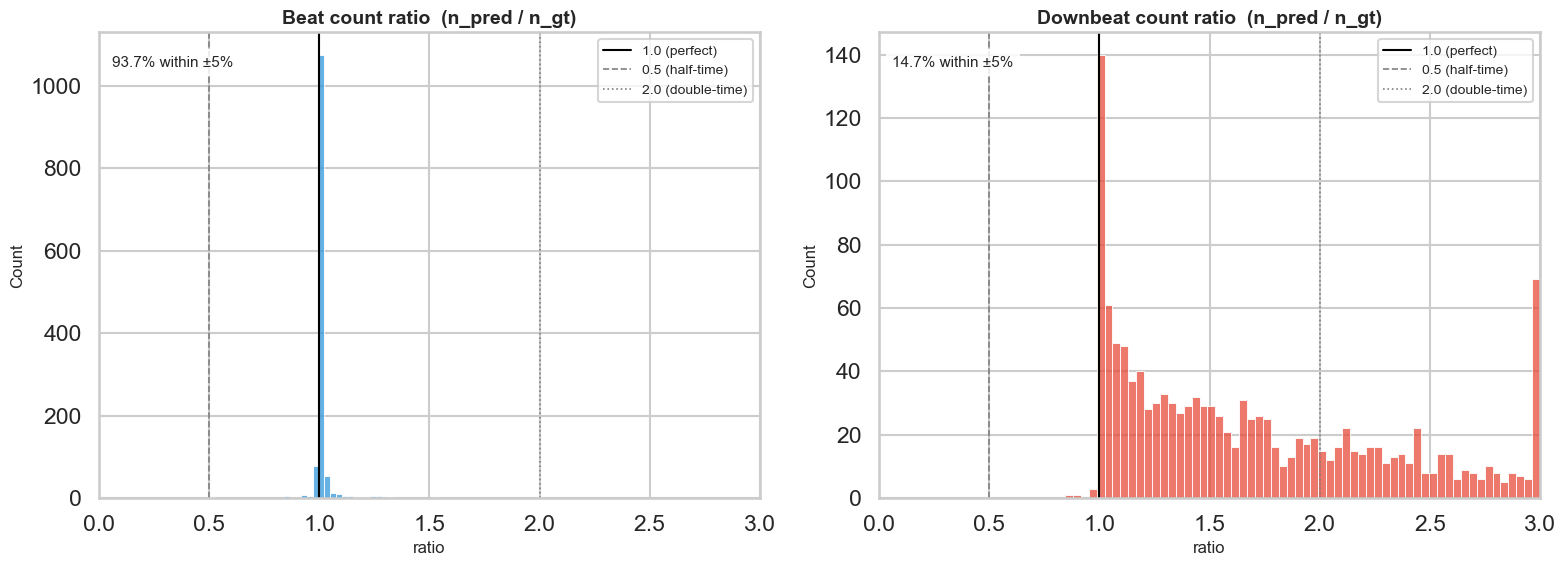

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, kind, color in zip(axes, ['beat','downbeat'], ['#3498db','#e74c3c']):
    ratio = df[f'{kind}_count_ratio'].dropna()
    sns.histplot(ratio.clip(0, 3), bins=60, color=color, ax=ax, edgecolor='white')
    ax.axvline(1.0, color='black', ls='-', lw=1.5, label='1.0 (perfect)')
    ax.axvline(0.5, color='gray',  ls='--', lw=1.2, label='0.5 (half-time)')
    ax.axvline(2.0, color='gray',  ls=':',  lw=1.2, label='2.0 (double-time)')
    ax.set_title(f'{kind.capitalize()} count ratio  (n_pred / n_gt)')
    ax.set_xlabel('ratio'); ax.set_xlim(0, 3); ax.legend(fontsize=10)
    near_perfect = ((ratio > 0.95) & (ratio < 1.05)).mean() * 100
    ax.text(0.02, 0.95, f'{near_perfect:.1f}% within ±5%', transform=ax.transAxes,
            va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.85))
plt.tight_layout(); plt.show()


## 7 — Inference speed

How long the model spent per track. The first run usually pays a JIT/warm-up
cost — easy to spot as an outlier here.


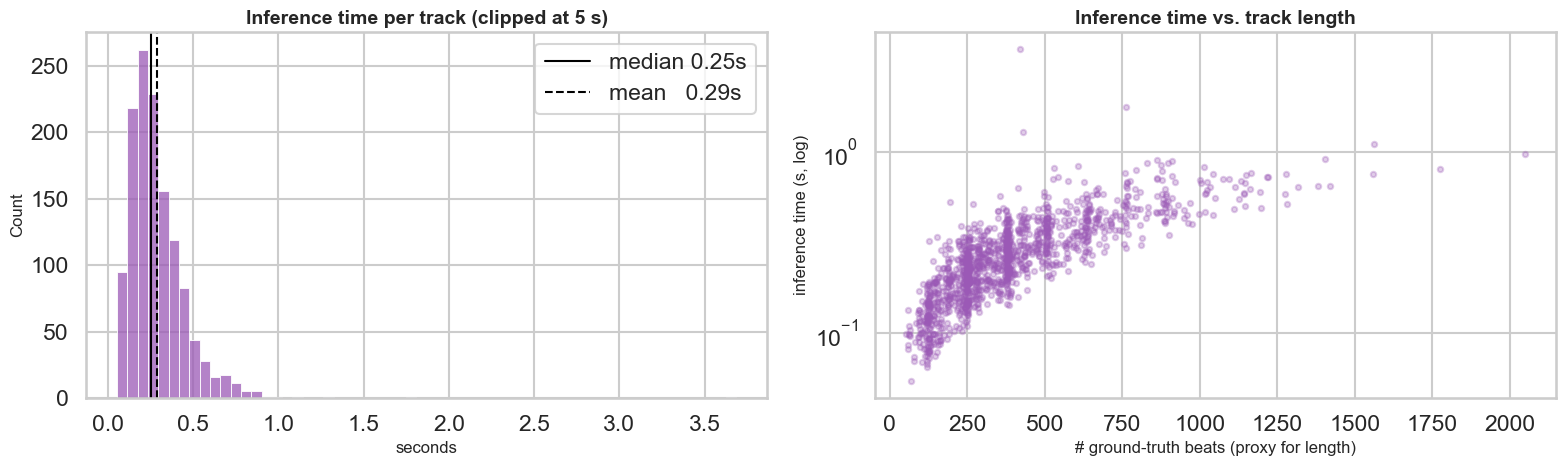

Inference time: median=0.253s   mean=0.290s   p95=0.59s   max=3.69s
Top 5 slowest tracks (likely warm-up + long files):


,track_id,n_gt_beats,infer_seconds
471,flanagant-cupbearers-mrazgjonese-1976-9f95221a,420,3.685
0,barronk-allgodschildren-drummondrrileyb-1990-8...,762,1.773
64,bleyp-turnaround-andersonjhirshfieldj-1997-304...,431,1.283
1184,tristanol-mymelancholybaby-indpweyburnt-1956-0...,1561,1.096
892,mehldaub-cta-grenadierlballardj-2006-9cdbc460,2050,0.972


In [38]:
infer = df['infer_seconds'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(infer.clip(upper=5), bins=60, color='#9b59b6', ax=axes[0], edgecolor='white')
axes[0].axvline(infer.median(), color='black', ls='-',  lw=1.5, label=f'median {infer.median():.2f}s')
axes[0].axvline(infer.mean(),   color='black', ls='--', lw=1.5, label=f'mean   {infer.mean():.2f}s')
axes[0].set_title('Inference time per track (clipped at 5 s)')
axes[0].set_xlabel('seconds'); axes[0].legend()

axes[1].scatter(df['n_gt_beats'], df['infer_seconds'], alpha=0.3, s=15, color='#9b59b6')
axes[1].set_yscale('log')
axes[1].set_xlabel('# ground-truth beats (proxy for length)')
axes[1].set_ylabel('inference time (s, log)')
axes[1].set_title('Inference time vs. track length')
plt.tight_layout(); plt.show()

print(f'Inference time: median={infer.median():.3f}s   mean={infer.mean():.3f}s   '
      f'p95={infer.quantile(0.95):.2f}s   max={infer.max():.2f}s')
print('Top 5 slowest tracks (likely warm-up + long files):')
df.nlargest(5, 'infer_seconds')[['track_id','n_gt_beats','infer_seconds']]


## 8 — Performance by band leader

JTD is built around a few canonical pianists. Some leaders may be
systematically harder — often the ones who play very rubato or out of
tempo (Jarrett, Evans solo intros).


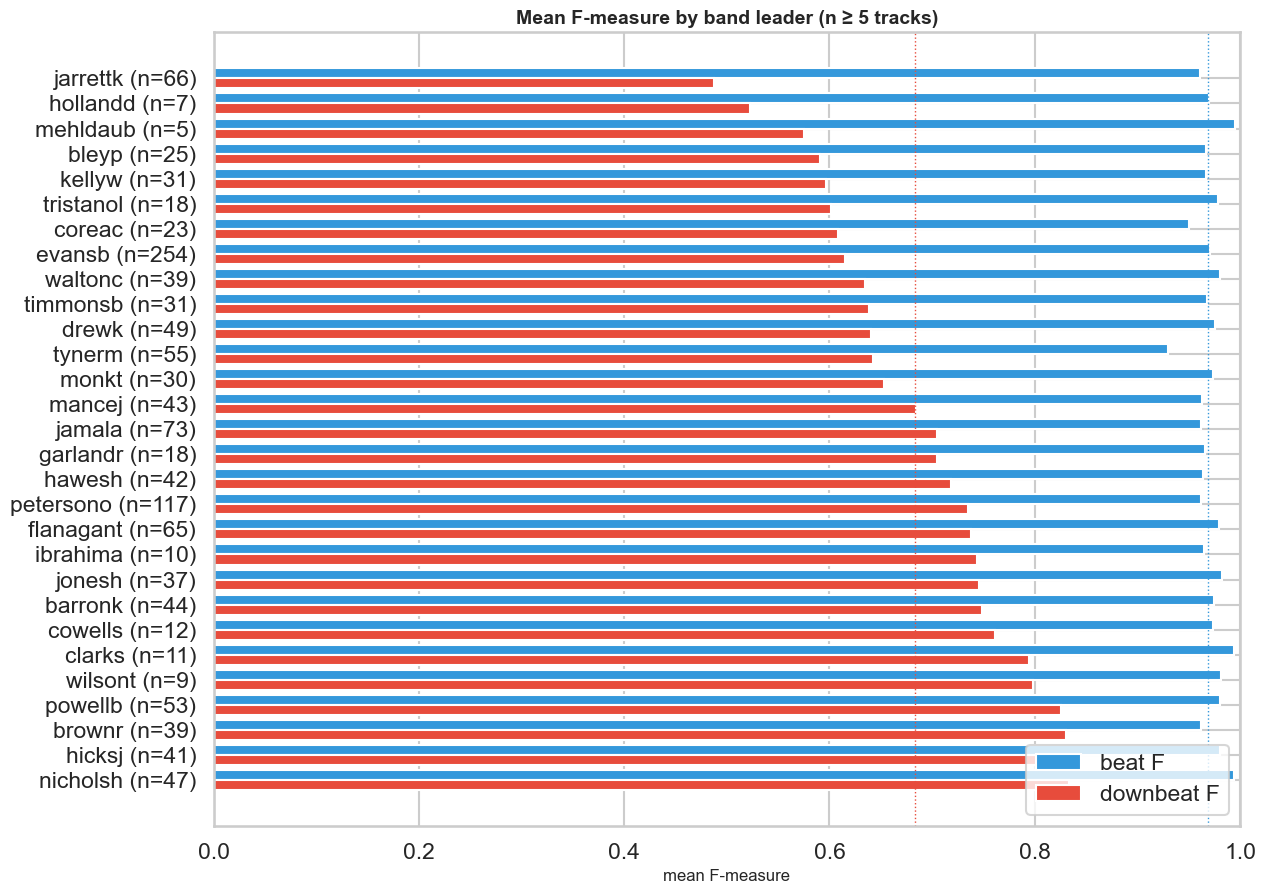

,n,beat_F,downbeat_F
leader,,,
jarrettk,66,0.961,0.487
hollandd,7,0.969,0.522
mehldaub,5,0.995,0.575
bleyp,25,0.967,0.591
kellyw,31,0.967,0.596
tristanol,18,0.978,0.602
coreac,23,0.950,0.608
evansb,254,0.970,0.615
waltonc,39,0.981,0.635


In [39]:
leader_stats = (df.groupby('leader')
                  .agg(n=('track_id','count'),
                       beat_F=('beat_F-measure','mean'),
                       downbeat_F=('downbeat_F-measure','mean'))
                  .sort_values('downbeat_F'))
leader_stats = leader_stats[leader_stats['n'] >= 5]

fig, ax = plt.subplots(figsize=(13, max(4, 0.32 * len(leader_stats))))
y = np.arange(len(leader_stats))
ax.barh(y - 0.2, leader_stats['beat_F'],     height=0.4, color='#3498db', label='beat F')
ax.barh(y + 0.2, leader_stats['downbeat_F'], height=0.4, color='#e74c3c', label='downbeat F')
ax.set_yticks(y); ax.set_yticklabels([f'{l} (n={n})' for l, n in zip(leader_stats.index, leader_stats['n'])])
ax.set_xlim(0, 1); ax.axvline(df['beat_F-measure'].mean(),     color='#3498db', ls=':', lw=1)
ax.axvline(df['downbeat_F-measure'].mean(), color='#e74c3c', ls=':', lw=1)
ax.set_xlabel('mean F-measure'); ax.set_title('Mean F-measure by band leader (n ≥ 5 tracks)')
ax.legend(loc='lower right'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

leader_stats.round(3)


## 9 — Performance across recording eras

Older recordings often have noisier audio, more variable mic placement, and
drummers using brushes — all of which can stress beat trackers.


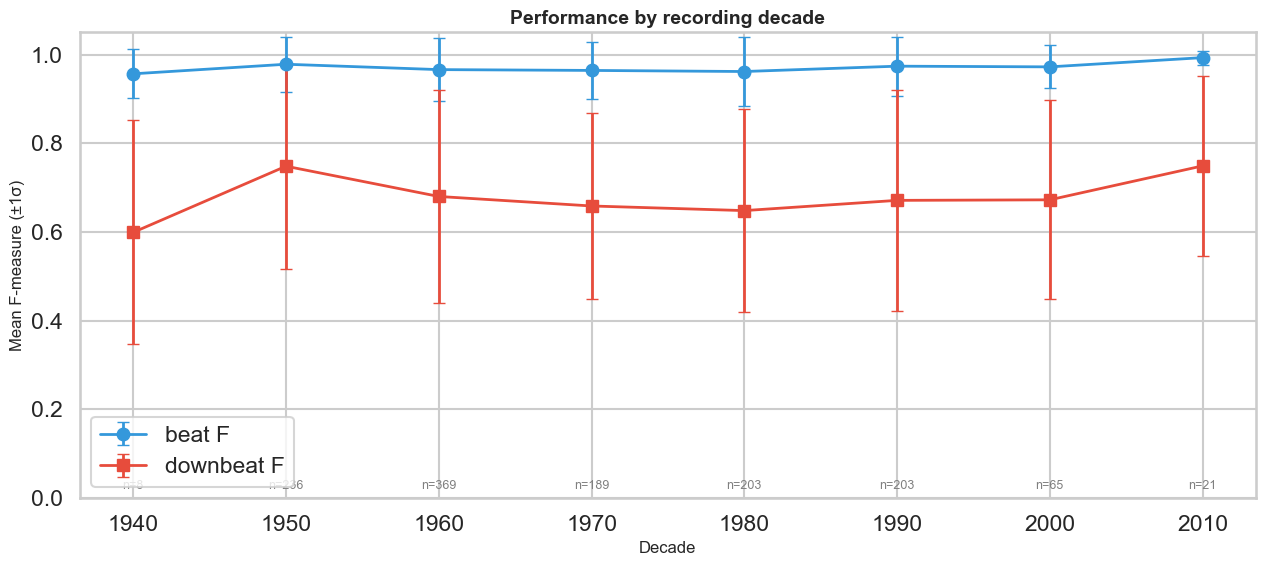

,n,beat_F,downbeat_F,beat_F_std,downbeat_F_std
decade,,,,,
1940,8,0.957,0.599,0.055,0.252
1950,236,0.978,0.748,0.063,0.232
1960,369,0.966,0.680,0.071,0.241
1970,189,0.964,0.659,0.065,0.209
1980,203,0.962,0.648,0.078,0.229
1990,203,0.974,0.671,0.067,0.250
2000,65,0.972,0.672,0.048,0.224
2010,21,0.993,0.749,0.016,0.204


In [40]:
decade_stats = (df.dropna(subset=['decade'])
                  .groupby('decade')
                  .agg(n=('track_id','count'),
                       beat_F=('beat_F-measure','mean'),
                       downbeat_F=('downbeat_F-measure','mean'),
                       beat_F_std=('beat_F-measure','std'),
                       downbeat_F_std=('downbeat_F-measure','std')))

fig, ax = plt.subplots(figsize=(13, 6))
x = decade_stats.index.astype(int)
ax.errorbar(x, decade_stats['beat_F'],     yerr=decade_stats['beat_F_std'],
            fmt='o-', color='#3498db', label='beat F', capsize=4, lw=2)
ax.errorbar(x, decade_stats['downbeat_F'], yerr=decade_stats['downbeat_F_std'],
            fmt='s-', color='#e74c3c', label='downbeat F', capsize=4, lw=2)
for xi, n in zip(x, decade_stats['n']):
    ax.text(xi, 0.02, f'n={n}', ha='center', fontsize=9, color='gray')
ax.set_ylim(0, 1.05); ax.set_xlabel('Decade'); ax.set_ylabel('Mean F-measure (±1σ)')
ax.set_title('Performance by recording decade')
ax.legend(); plt.tight_layout(); plt.show()

decade_stats.round(3)


## 10 — Failure modes

Three patterns worth distinguishing:

1. **Pure downbeat collapse** — beats ≥ 0.8 but downbeats ≈ 0.
   Phase ambiguity: the model found the pulse but locked onto the wrong bar position.
2. **Half-time / double-time** — count ratio outside [0.7, 1.4].
3. **Total miss** — both metrics < 0.5 (rubato, very sparse drumming, etc.).


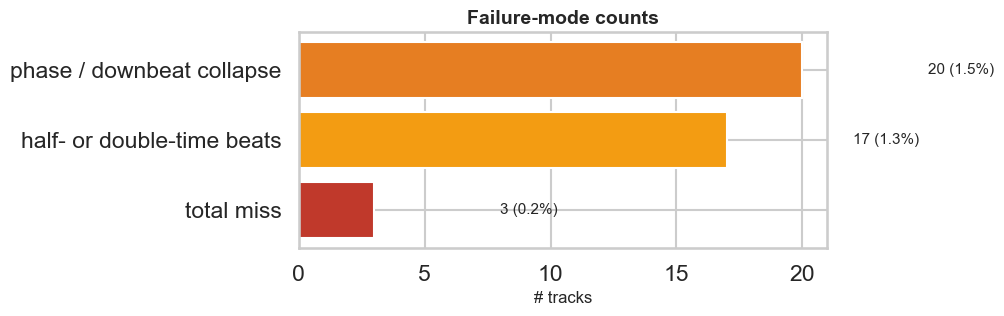

,failure_mode,n_tracks,pct
0,phase / downbeat collapse,20,1.545595
1,half- or double-time beats,17,1.313756
2,total miss,3,0.231839


In [41]:
phase_fail   = df[(df['beat_F-measure'] > 0.8) & (df['downbeat_F-measure'] < 0.2)]
halftime     = df[(df['beat_count_ratio'] < 0.7) | (df['beat_count_ratio'] > 1.4)]
total_miss   = df[(df['beat_F-measure'] < 0.5) & (df['downbeat_F-measure'] < 0.5)]

summary = pd.DataFrame({
    'failure_mode': ['phase / downbeat collapse', 'half- or double-time beats', 'total miss'],
    'n_tracks':     [len(phase_fail), len(halftime), len(total_miss)],
    'pct':          [len(phase_fail)/len(df)*100, len(halftime)/len(df)*100, len(total_miss)/len(df)*100],
})

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.barh(summary['failure_mode'], summary['n_tracks'],
        color=['#e67e22','#f39c12','#c0392b'])
for i, (n, p) in enumerate(zip(summary['n_tracks'], summary['pct'])):
    ax.text(n + 5, i, f'{n} ({p:.1f}%)', va='center', fontsize=11)
ax.set_xlabel('# tracks'); ax.set_title('Failure-mode counts')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

summary


In [42]:
print('—— phase-collapse exemplars (beats good, downbeats failed) ——')
phase_fail.nsmallest(10, 'downbeat_F-measure')[
    ['track_id','beat_F-measure','downbeat_F-measure','beat_count_ratio','downbeat_count_ratio']
]


—— phase-collapse exemplars (beats good, downbeats failed) ——


,track_id,beat_F-measure,downbeat_F-measure,beat_count_ratio,downbeat_count_ratio
164,drewk-bluesville-wrightespecsc-1953-0e9a33ad,1.000000,0.000000,1.000000,1.105263
782,jonesh-bluemonk-mrazgwashingtonk-1991-c20e31ce,0.996364,0.000000,1.006849,1.805556
999,petersono-flymetothemoon-jonessdurhamb-1970-53...,1.000000,0.000000,1.000000,1.100000
336,evansb-nightandday-jonessjoep-1958-8d805cd6,0.998331,0.071429,1.000000,1.936709
794,jonesh-interface-mrazgwashingtonk-1991-5076deb8,0.998110,0.088050,1.003610,1.471429
1010,petersono-itaintnecessarilyso-brownrthigpene-1...,0.874704,0.096774,1.022936,1.370370
228,evansb-beautifullovetake2-lafarosmotianp-1960-...,1.000000,0.107143,1.000000,1.064516
6,barronk-catchandrelease-kitagawakbladeb-2005-4...,1.000000,0.107914,1.000000,1.285714
843,kellyw-swingingtilthegirlscome-chamberspcobbj-...,1.000000,0.121795,1.002160,1.801724
687,jamala-softwinds-crosbyifournierv-1961-21645f01,1.000000,0.140351,1.005263,1.520833


In [43]:
print('—— half/double-time exemplars (count ratio far from 1.0) ——')
halftime.assign(abs_dev=lambda d: (d['beat_count_ratio'] - 1).abs())\
        .nlargest(10, 'abs_dev')[
            ['track_id','n_gt_beats','n_pred_beats','beat_count_ratio','beat_F-measure']
        ]


—— half/double-time exemplars (count ratio far from 1.0) ——


,track_id,n_gt_beats,n_pred_beats,beat_count_ratio,beat_F-measure
1213,tynerm-lazybird-davissjonese-1962-09dff582,248,512,2.064516,0.640777
680,jamala-oneformiles-nasserjlampkinc-1964-c68f6f7d,418,837,2.002392,0.646382
1014,petersono-itsallrightwithme-brownrthigpene-195...,169,338,2.000000,0.632479
1129,powellb-shawnuff-pettifordoclarkek-1960-9b2240ad,385,726,1.885714,0.676608
202,drewk-yesterdaysalternatetake-russellcblakeya-...,320,565,1.765625,0.710900
756,jarrettk-rainbow-hadencmotianp-1972-2c0f6494,392,682,1.739796,0.693564
727,jarrettk-churchdreams-hadencmotianp-1967-f2d04238,352,604,1.715909,0.622951
487,flanagant-lets-washingtonpnashl-1997-03bbc9f5,484,757,1.564050,0.771667
1066,petersono-thereisnogreaterlove-brownrthigpene-...,319,491,1.539185,0.672634
750,jarrettk-longtimegonebutnot-hadencmotianp-1967...,298,457,1.533557,0.669492


## 11 — Estimated tempo from predicted beats

We don't have ground-truth tempo per track, but we can read the predicted
beat times back from `results/preds/*.npz` and compute the median IBI
(inter-beat-interval) → tempo. This gives a sense of the tempo range the
model is operating over and whether the *worst* tracks cluster at tempo
extremes.


In [44]:
def estimate_tempo_from_npz(track_id):
    p = PREDS_DIR / f'{track_id}.npz'
    if not p.exists():
        return np.nan
    try:
        data = np.load(p)
        beats = data['beats']
        if len(beats) < 4:
            return np.nan
        ibis = np.diff(beats)
        ibis = ibis[(ibis > 0.1) & (ibis < 2.0)]
        if len(ibis) == 0:
            return np.nan
        return 60.0 / np.median(ibis)
    except Exception:
        return np.nan

df['est_bpm'] = df['track_id'].apply(estimate_tempo_from_npz)
valid_bpm = df['est_bpm'].dropna()
print(f'Recovered tempo for {len(valid_bpm)}/{len(df)} tracks   '
      f'(median {valid_bpm.median():.1f} BPM, p5 {valid_bpm.quantile(0.05):.1f}, '
      f'p95 {valid_bpm.quantile(0.95):.1f})')


Recovered tempo for 1294/1294 tracks   (median 187.5 BPM, p5 111.1, p95 272.7)


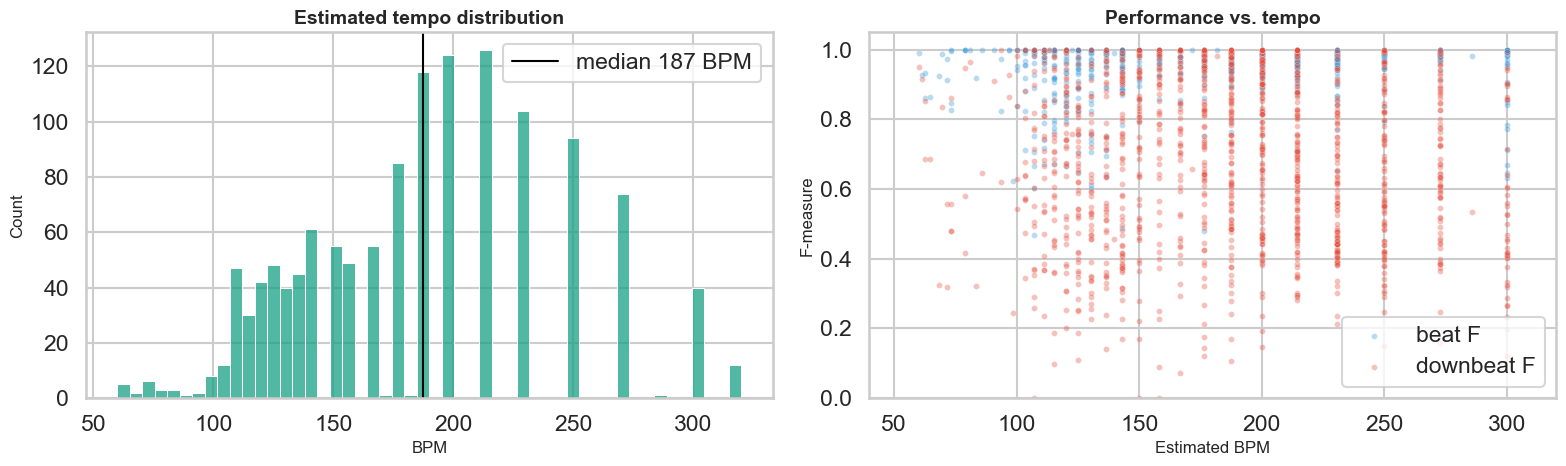

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(valid_bpm.clip(40, 320), bins=50, color='#16a085', ax=axes[0], edgecolor='white')
axes[0].axvline(valid_bpm.median(), color='black', lw=1.5, label=f'median {valid_bpm.median():.0f} BPM')
axes[0].set_title('Estimated tempo distribution'); axes[0].set_xlabel('BPM'); axes[0].legend()

sns.scatterplot(data=df.dropna(subset=['est_bpm']),
                x='est_bpm', y='beat_F-measure', alpha=0.35, s=18,
                color='#3498db', label='beat F', ax=axes[1])
sns.scatterplot(data=df.dropna(subset=['est_bpm']),
                x='est_bpm', y='downbeat_F-measure', alpha=0.35, s=18,
                color='#e74c3c', label='downbeat F', ax=axes[1])
axes[1].set_xlim(40, 320); axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Estimated BPM'); axes[1].set_ylabel('F-measure')
axes[1].set_title('Performance vs. tempo')
plt.tight_layout(); plt.show()


## 12 — Hardest tracks

Top-10 worst by each headline metric. Use these as candidates for the
single-track investigation cells below.


In [46]:
worst_beat = (df[df['status'] == 'ok']
                .nsmallest(10, 'beat_F-measure')
                [['track_id','beat_F-measure','downbeat_F-measure',
                  'beat_count_ratio','est_bpm']])
worst_beat.style.background_gradient(cmap='Reds_r', subset=['beat_F-measure'])\
                 .format({'beat_F-measure':'{:.3f}','downbeat_F-measure':'{:.3f}',
                          'beat_count_ratio':'{:.2f}','est_bpm':'{:.0f}'})


,track_id,beat_F-measure,downbeat_F-measure,beat_count_ratio,est_bpm
812,jonesh-thingsaintwhattheyused-drummondrhigginsb-1990-4a0846a7,0.468,0.369,1.41,107
386,evansb-thetwolonelypeople-johnsonmlabarberaj-1980-e5016fe2,0.480,0.145,1.18,176
695,jamala-stompinatthesavoy-crosbyifournierv-1958-dddc1bc7,0.488,0.417,1.01,143
1043,petersono-satindoll-brownrthigpene-1964-f07c7707,0.602,0.270,0.93,130
43,barronk-youdontknowwhatlove-drummondrrileyb-1996-15956096,0.602,0.290,0.85,107
129,coreac-myoneandonlylove-patituccijweckld-1989-3bb85aae,0.611,0.228,0.96,130
727,jarrettk-churchdreams-hadencmotianp-1967-f2d04238,0.623,0.244,1.72,98
1014,petersono-itsallrightwithme-brownrthigpene-1959-bb8fd89b,0.632,0.264,2.00,300
553,hawesh-eveningtrane-vinnegarlduckd-1970-27f36295,0.638,0.238,0.98,136
1213,tynerm-lazybird-davissjonese-1962-09dff582,0.641,0.178,2.06,333


In [47]:
worst_db = (df[df['status'] == 'ok']
              .nsmallest(10, 'downbeat_F-measure')
              [['track_id','beat_F-measure','downbeat_F-measure',
                'downbeat_count_ratio','est_bpm']])
worst_db.style.background_gradient(cmap='Reds_r', subset=['downbeat_F-measure'])\
                .format({'beat_F-measure':'{:.3f}','downbeat_F-measure':'{:.3f}',
                         'downbeat_count_ratio':'{:.2f}','est_bpm':'{:.0f}'})


,track_id,beat_F-measure,downbeat_F-measure,downbeat_count_ratio,est_bpm
164,drewk-bluesville-wrightespecsc-1953-0e9a33ad,1.000,0.000,1.11,158
782,jonesh-bluemonk-mrazgwashingtonk-1991-c20e31ce,0.996,0.000,1.81,107
999,petersono-flymetothemoon-jonessdurhamb-1970-53a13b46,1.000,0.000,1.10,150
336,evansb-nightandday-jonessjoep-1958-8d805cd6,0.998,0.071,1.94,167
794,jonesh-interface-mrazgwashingtonk-1991-5076deb8,0.998,0.088,1.47,158
1010,petersono-itaintnecessarilyso-brownrthigpene-1960-aadc1e26,0.875,0.097,1.37,115
228,evansb-beautifullovetake2-lafarosmotianp-1960-3ab52308,1.000,0.107,1.06,187
6,barronk-catchandrelease-kitagawakbladeb-2005-432b4129,1.000,0.108,1.29,125
202,drewk-yesterdaysalternatetake-russellcblakeya-1951-722999c7,0.711,0.121,2.09,300
843,kellyw-swingingtilthegirlscome-chamberspcobbj-1964-9c90c1d0,1.000,0.122,1.80,176


---
## 13 — Single-track investigation

These cells require the audio + model stacks (`librosa`, `soxr`, `torch`).
If the imports at the top failed they will be skipped automatically.


In [48]:
def play_with_clicks(audio_path, beats, downbeats=None):
    if not AUDIO_OK:
        print('audio stack unavailable; skipping playback.')
        return None
    y, sr = librosa.load(audio_path)
    clicks = librosa.clicks(times=beats, sr=sr, length=len(y),
                            click_freq=1000, click_duration=0.1)
    if downbeats is not None:
        db_clicks = librosa.clicks(times=downbeats, sr=sr, length=len(y),
                                   click_freq=500, click_duration=0.1)
        clicks = clicks + db_clicks
    return ipd.Audio(y + clicks * 0.5, rate=sr)


### 13a — Bill Evans, *Like Someone in Love* (1980) — phase-collapse case

Beats are tracked well but downbeats fail completely (downbeat F ≈ 0).


In [49]:
target_track = 'evansb-likesomeoneinlove-johnsonmlabarberaj-1980-c67ffd5a'
df[df['track_id'] == target_track][
    ['track_id','beat_F-measure','downbeat_F-measure',
     'n_gt_beats','n_pred_beats','n_gt_downbeats','n_pred_downbeats']
]


,track_id,beat_F-measure,downbeat_F-measure,n_gt_beats,n_pred_beats,n_gt_downbeats,n_pred_downbeats
300,evansb-likesomeoneinlove-johnsonmlabarberaj-19...,1.0,0.412587,386,386,96,209


In [50]:
if MODEL_OK:
    checkpoint_path = './beat_this/checkpoint/final0.ckpt'
    audio_path = './test_audio/evansb-thetwolonelypeople-johnsonmlabarberaj-1980-e5016fe2.wav'
    print(f"Running inference on: {audio_path}")
    beat, downbeat = run_beat_this(checkpoint_path=checkpoint_path, audio_path=audio_path)
    plot_beats(audio_path, beat, downbeat)
else:
    print('model stack unavailable; install soxr/torch to run inference.')

Running inference on: ./test_audio/evansb-thetwolonelypeople-johnsonmlabarberaj-1980-e5016fe2.wav
Downloading: "https://cloud.cp.jku.at/public.php/dav/files/7ik4RrBKTS273gp/./beat_this/checkpoint/final0.ckpt.ckpt" to /Users/robbietylman/.cache/torch/hub/checkpoints/beat_this-./beat_this/checkpoint/final0.ckpt.ckpt


ValueError: ('Could not load the checkpoint given the provided name', './beat_this/checkpoint/final0.ckpt')

In [ ]:
if MODEL_OK and AUDIO_OK:
    display(play_with_clicks(audio_path, beat, downbeat))


### 13b — Bill Evans, *The Two Lonely People* (1980) — lowest beat F-measure

Around 30 s the bass drops to half-time and the model halves its tempo with it.


In [ ]:
print('Top 5 tracks with lowest beat F-measure:')
df[['track_id','beat_F-measure','downbeat_F-measure']]\
  .sort_values('beat_F-measure').head()


Top 5 tracks with lowest beat F-measure:


,track_id,beat_F-measure,downbeat_F-measure
386,evansb-thetwolonelypeople-johnsonmlabarberaj-1...,0.313390,0.110429
727,jarrettk-churchdreams-hadencmotianp-1967-f2d04238,0.327273,0.246914
129,coreac-myoneandonlylove-patituccijweckld-1989-...,0.363636,0.139130
747,jarrettk-ithoughtaboutyou-peacockgdejohnettej-...,0.375000,0.269231
1230,tynerm-roundmidnight-sharpeascotta-1989-c2cc8b90,0.376667,0.050000


In [ ]:
if MODEL_OK:
    checkpoint_path = './beat_this/checkpoint/final0.ckpt'
    audio_path = './test_audio/evansb-thetwolonelypeople-johnsonmlabarberaj-1980-e5016fe2.wav'
    print(f"Running inference on: {audio_path}")
    beat, downbeat = run_beat_this(checkpoint_path=checkpoint_path, audio_path=audio_path)
    plot_beats(audio_path, beat, downbeat)
else:
    print('model stack unavailable; install soxr/torch to run inference.')

model stack unavailable; install soxr/torch to run inference.


In [ ]:
if MODEL_OK and AUDIO_OK:
    display(play_with_clicks(audio_path, beat, downbeat))


*Observation: at ~30 s the walking bass momentarily implies half-time and the
model latches on, halving its predicted tempo until the cymbal pattern reasserts.*
